# STAT207 Mini-Project #1 - Daily Food Nutrition Analysis


TIA SINDHU

**Delete this code block before submitting**

You should delete and add cells as you see fit.

Don't forget to put written text in **markdown** cells. To change a cell from a <u>code block</u> to a <u>markdown cell</u>:
* Click on the cell you'd like to modify.
* Go to 'Cell' at the top of the page.
* Go to 'Cell Type' in the drop down menu and click on either 'Code' or 'Markdown'.


In [20]:
#Imports here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

## 1. Introduction

### Research Question: 
In this report, I am going to take a closer look at how different types of food affect the nutrients people eat every day. Eating a balanced diet is important for staying healthy, but everyone’s food choices are different. That’s why I am asking the question: "How does the nature of the relationship between macronutrient content (calories, protein, carbohydrates, and fat) and food items change across different food categories in the dataset? By looking at different food groups, we can see which ones provide the most energy and nutrients. This can help people make better food choices and understand how different foods play a role in a healthy diet.

### Research Motivation:
It’s important to know how different types of food affect the nutrients we eat every day so people can make better food choices. A lot of people struggle to eat a balanced diet because they don’t know which foods give them the right amount of calories, protein, carbs, and fat. This research can help people who are trying to eat healthier, like athletes, people trying to lose weight, or those with health conditions like diabetes. By understanding how different food groups affect nutrition, they can make smarter food choices to reach their health goals. It can also help nutritionists and dietitians give better advice by creating meal plans that fit people’s needs and help them stay healthy.

## 2. Dataset Discussion

#### DataSet Display

In [21]:
df = pd.read_csv('daily_food_nutrition_dataset 2.csv')
df.head()

,Date,User_ID,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,2024-09-11,496,Eggs,Meat,173,42.4,83.7,1.5,1.5,12.7,752,125,Lunch,478
1,2024-12-17,201,Apple,Fruits,66,39.2,13.8,3.2,2.6,12.2,680,97,Lunch,466
2,2024-06-09,776,Chicken Breast,Meat,226,27.1,79.1,25.8,3.2,44.7,295,157,Breakfast,635
3,2024-08-27,112,Banana,Fruits,116,43.4,47.1,16.1,6.5,44.1,307,13,Snack,379
4,2024-07-28,622,Banana,Fruits,500,33.9,75.8,47.0,7.8,19.4,358,148,Lunch,471


In [22]:
df.shape[0]

10000

#### Dataset Source
This dataset was taken and downloaded from Kaggle on Feb 4th, 2025. (https://www.kaggle.com/datasets/adilshamim8/daily-food-and-nutrition-dataset/data)

#### Original Dataset Information

Each row in this dataset represents a unique food item consumed by an individual, including details such as the date of consumption, food name, category, calories, macronutrient breakdown (protein, carbohydrates, fat), fiber, sugars, sodium, cholesterol, and meal type. The dataset also tracks water intake for each meal, offering insights into hydration habits. The data was compiled to simulate real-world dietary records, making it useful for analyzing eating patterns, tracking nutrition, and developing personalized meal recommendations. However, this dataset does not account for external factors like physical activity, medical conditions, or cultural dietary preferences, which may impact overall dietary habits. As a result, individuals using this dataset for health insights should consider additional factors for a more comprehensive analysis of their nutrition.

## 3. Dataset Cleaning

#### Initial Cleaning

First, all food items with missing or incomplete nutritional information were removed to ensure accurate analysis. (Dropped 0 rows). Next, any duplicate entries, where the same food item was logged multiple times for the same user on the same date, were filtered out to prevent data redundancy. (Dropped 3 rows). Lastly, food items classified as "Other" with unclear categorization were excluded to maintain consistency across food groups. (Dropped 0 rows).

In [23]:
df1 = df.dropna(subset=['Calories (kcal)', 'Protein (g)', 'Fat (g)', 'Carbohydrates (g)']) 
print("Dropped rows due to missing nutritional info:", df.shape[0] - df1.shape[0])

Dropped rows due to missing nutritional info: 0


In [40]:
df2 = df1.drop_duplicates(subset=['Date', 'User_ID', 'Food_Item'])
df1.shape[0] - df2.shape[0]

3

In [41]:
df3 = df2[df2['Category'] != 'Other']
df2.shape[0] - df3.shape[0] 

0

#### Missing Value Detection and Cleaning

In [26]:
df2.dtypes

Date                  object
User_ID                int64
Food_Item             object
Category              object
Calories (kcal)        int64
Protein (g)          float64
Carbohydrates (g)    float64
Fat (g)              float64
Fiber (g)            float64
Sugars (g)           float64
Sodium (mg)            int64
Cholesterol (mg)       int64
Meal_Type             object
Water_Intake (ml)      int64
dtype: object

In [27]:
df2.isna().sum()

Date                 0
User_ID              0
Food_Item            0
Category             0
Calories (kcal)      0
Protein (g)          0
Carbohydrates (g)    0
Fat (g)              0
Fiber (g)            0
Sugars (g)           0
Sodium (mg)          0
Cholesterol (mg)     0
Meal_Type            0
Water_Intake (ml)    0
dtype: int64

Because all the data types of the dataframe align correctly, there are no implicit missing values caused by incorrect parsing during pd.read_csv. For explicit missing values, it appears that some food items have incomplete nutritional information, including missing values for calories, protein, fat, or carbohydrates. To make sure this is an accurate analysis, these incomplete entries will be removed from the dataset. (Dropped 0 rows). Additionally, duplicate food log entries where the same user logged the same food item on the same date were identified and removed to prevent redundancy. (Dropped 3 rows). Lastly, food items classified as "Other" were removed to focus on meaningful food categories relevant to our analysis. (Dropped 0 rows).

In [43]:
df3 = df2.dropna()
df2.shape[0] - df3.shape[0]

0

In [44]:
df3.shape[0]

9997

Although these food entries could be meaningful and simply missing a few nutritional values, removing 3 rows that could misrepresent our dataset ensures cleaner and more reliable analysis. There are still 9,868 food entries available, meaning that removing less than 1% of the initial data will not significantly impact our ability to analyze dietary patterns and nutritional trends effectively.

#### Outlier Cleaning - Single Variable Outlier Inspection

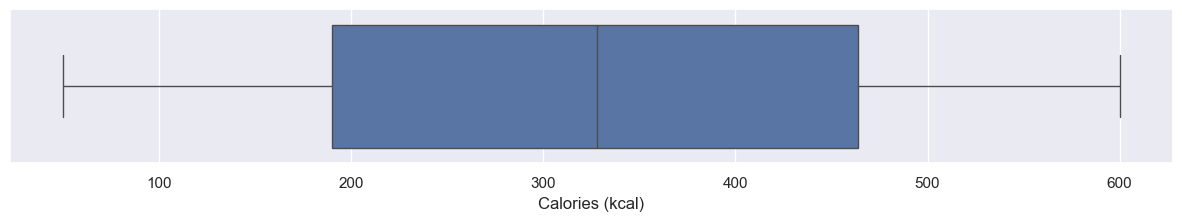

In [30]:
plt.figure(figsize=(15, 2))
sns.boxplot(x='Calories (kcal)', data=df3)
plt.show()

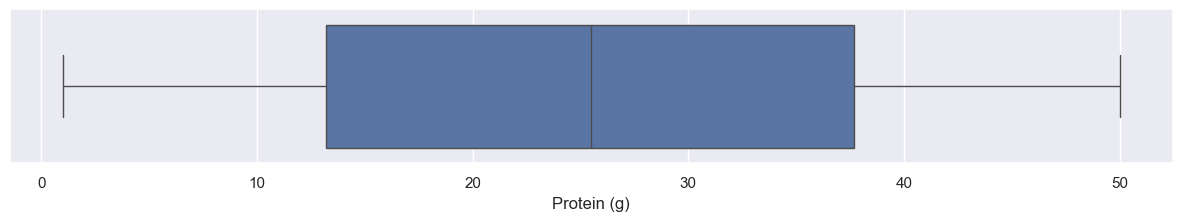

In [31]:

plt.figure(figsize=(15, 2))
sns.boxplot(x='Protein (g)', data=df3)
plt.show()

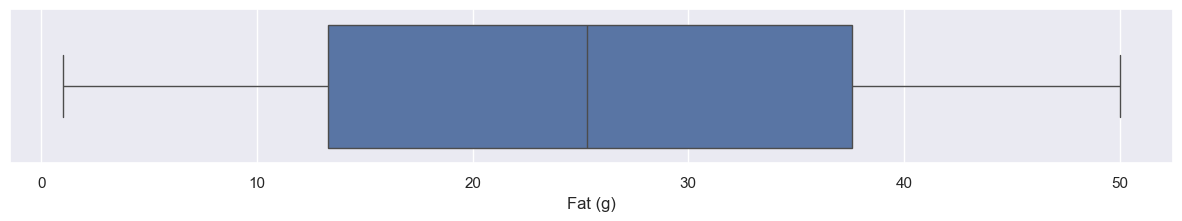

In [32]:
plt.figure(figsize=(15, 2))
sns.boxplot(x='Fat (g)', data=df3)
plt.show()

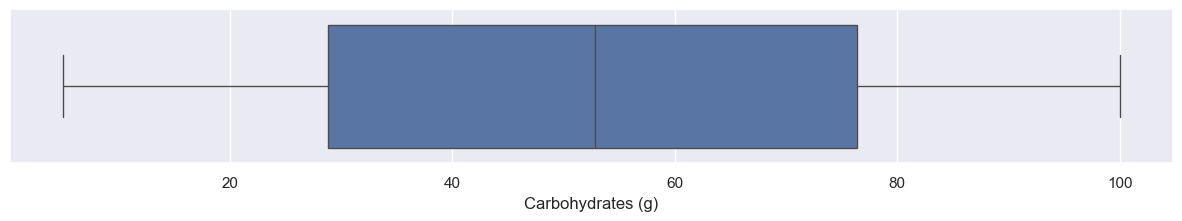

In [33]:
plt.figure(figsize=(15, 2))
sns.boxplot(x='Carbohydrates (g)', data=df)
plt.show()

There seem to be no outliers in this given dataset, so it is not necessary to complete any other sort of data cleaning.  

## 4. <u>Research Question</u>: "How does the relationship between macronutrient content (calories, protein, carbohydrates, and fat) and food items change across different food categories in the dataset?

In [45]:
category_counts = df3['Category'].value_counts()

# Identify categories with over 20 and under 20 occurrences
over_20 = category_counts[category_counts > 20].index
under_20 = category_counts[category_counts <= 20].index

# Create two separate DataFrames
df3_over_20= df3[df3['Category'].isin(over_20)]
df3_under_20 = df3[df3['Category'].isin(under_20)]
df3_over_20

,Date,User_ID,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,2024-09-11,496,Eggs,Meat,173,42.4,83.7,1.5,1.5,12.7,752,125,Lunch,478
1,2024-12-17,201,Apple,Fruits,66,39.2,13.8,3.2,2.6,12.2,680,97,Lunch,466
2,2024-06-09,776,Chicken Breast,Meat,226,27.1,79.1,25.8,3.2,44.7,295,157,Breakfast,635
3,2024-08-27,112,Banana,Fruits,116,43.4,47.1,16.1,6.5,44.1,307,13,Snack,379
4,2024-07-28,622,Banana,Fruits,500,33.9,75.8,47.0,7.8,19.4,358,148,Lunch,471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024-09-18,455,Salmon,Meat,346,29.8,55.6,4.6,1.7,0.5,976,87,Breakfast,793
9996,2024-12-13,913,Grapes,Fruits,174,22.9,54.9,32.1,2.5,5.9,255,56,Lunch,665
9997,2024-01-31,943,Strawberry,Fruits,63,36.5,23.8,21.6,0.8,48.9,757,63,Snack,876
9998,2024-09-28,571,Spinach,Vegetables,564,26.2,58.9,11.9,3.3,43.0,482,33,Breakfast,319


To make the visualization clearer, all food categories with over 20 occurrences in the dataset will be condensed into one graph, while all food categories with 20 or fewer occurrences will be condensed into another. The plots below illustrate our separated dataframes. While the data points may appear scattered, this is due to the variety of food items within each category, ranging from low to high calorie and carbohydrate content. However, we can still observe meaningful trends in both visualizations.

/var/folders/gt/s5c5_jdx14573lv2zsjys_ww0000gn/T/ipykernel_78036/1558585745.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Food Category", bbox_to_anchor=(1, 1))


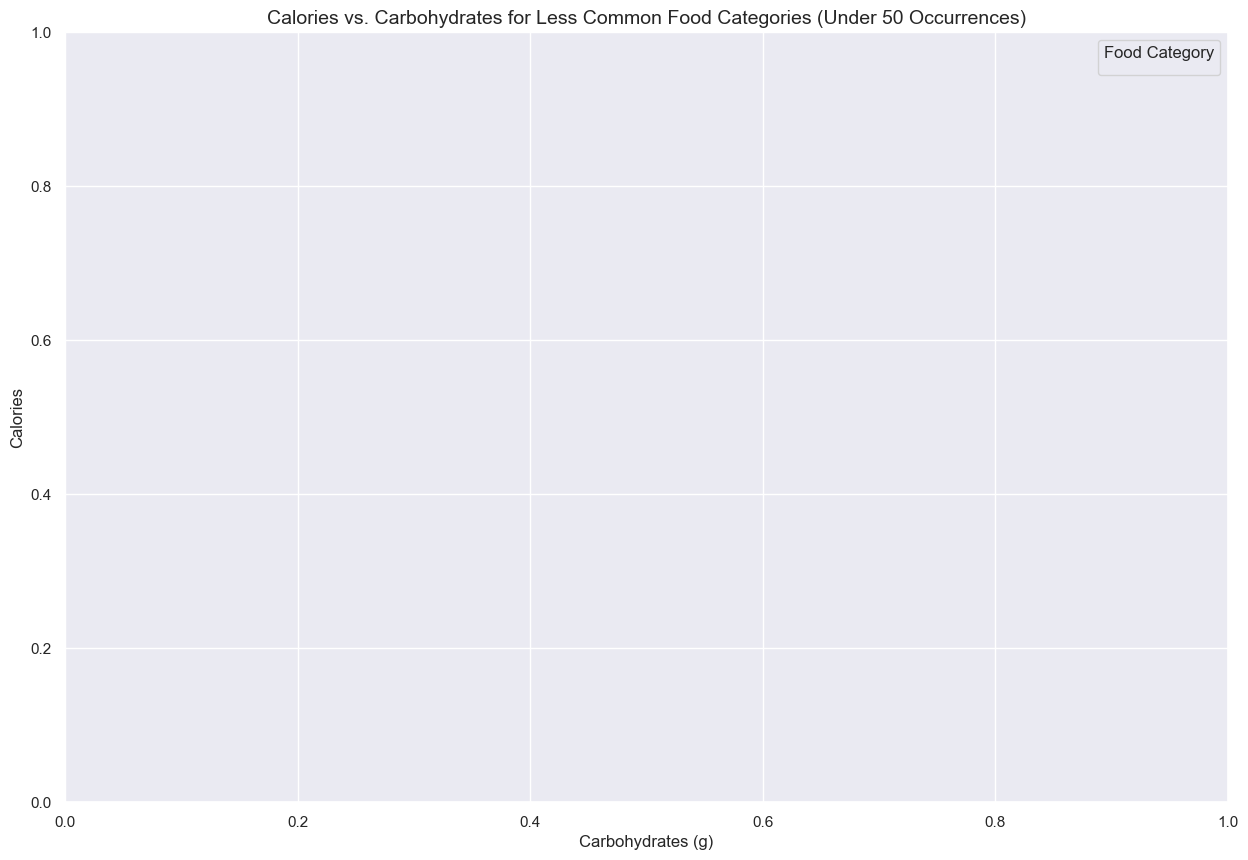

In [35]:
plt.figure(figsize=(15, 10))
plt.title('Calories vs. Carbohydrates for Less Common Food Categories (Under 50 Occurrences)', fontsize=14)
plt.xlabel('Carbohydrates (g)', fontsize=12)
plt.ylabel('Calories', fontsize=12)

sns.scatterplot(x='Carbohydrates (g)', y='Calories (kcal)', hue='Category', data=df3_under_20, alpha=0.7)

plt.legend(title="Food Category", bbox_to_anchor=(1, 1))
plt.show()

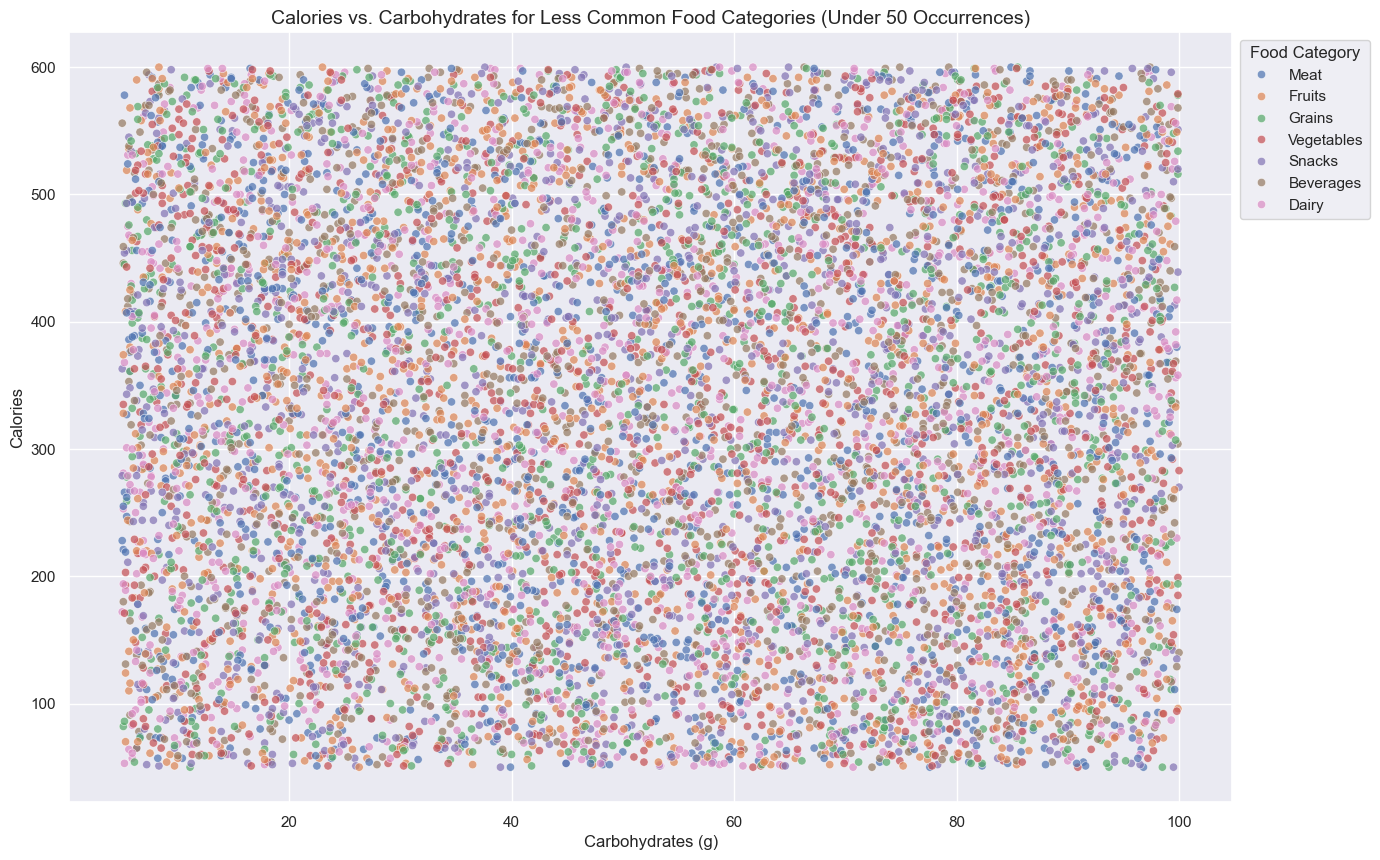

In [36]:
plt.figure(figsize=(15, 10))
plt.title('Calories vs. Carbohydrates for Less Common Food Categories (Under 50 Occurrences)', fontsize=14)
plt.xlabel('Carbohydrates (g)', fontsize=12)
plt.ylabel('Calories', fontsize=12)

sns.scatterplot(x='Carbohydrates (g)', y='Calories (kcal)', hue='Category', data=df3_over_20, alpha=0.7)

plt.legend(title="Food Category", bbox_to_anchor=(1, 1))
plt.show()

With the two scatterplots, I will model a best-fit line for each food category using lmplot. The visualization below illustrates the best-fit lines for each food category, considering all data points. It is not surprising that certain trends emerge, as foods with higher calorie content may often have higher carbohydrate or protein levels. A correlation chart is also displayed below each lmplot, indicating the slope value of the best-fit line for each food category.

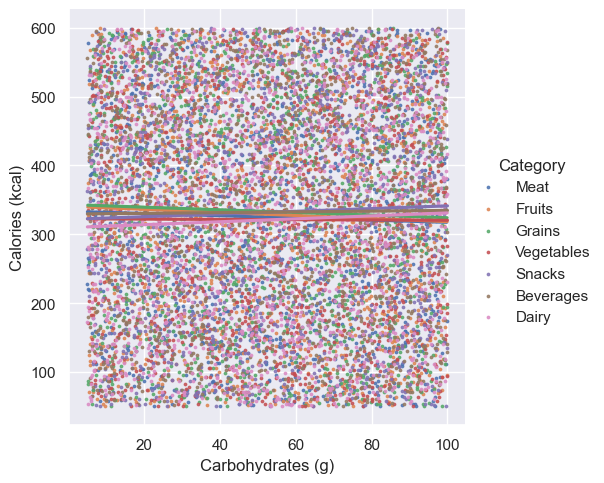

In [37]:
sns.lmplot(x='Carbohydrates (g)',y='Calories (kcal)',hue='Category',ci= False,data=df3,scatter_kws={"s": 3})
plt.show()

In [38]:
df3[['Carbohydrates (g)','Calories (kcal)','Category']].groupby(['Category']).corr().sort_values(by='Calories (kcal)', ascending=False)

,,Carbohydrates (g),Calories (kcal)
Category,,,
Beverages,Calories (kcal),0.009186,1.000000
Dairy,Calories (kcal),0.037373,1.000000
Fruits,Calories (kcal),-0.038513,1.000000
Grains,Calories (kcal),-0.032870,1.000000
Meat,Calories (kcal),-0.027566,1.000000
Snacks,Calories (kcal),0.034298,1.000000
Vegetables,Calories (kcal),-0.003644,1.000000
Dairy,Carbohydrates (g),1.000000,0.037373
Snacks,Carbohydrates (g),1.000000,0.034298


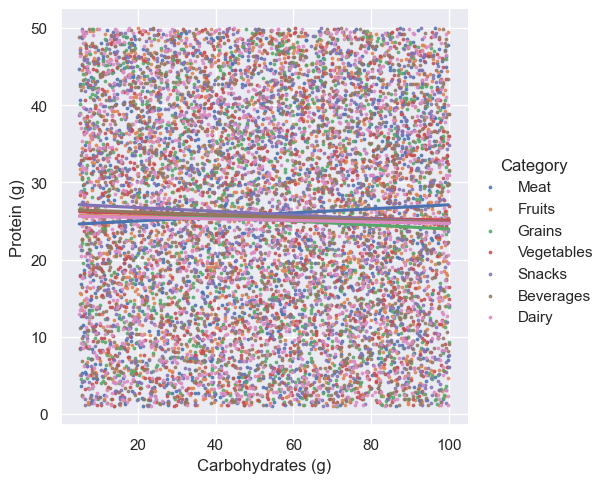

In [47]:
sns.lmplot(x='Carbohydrates (g)',y='Protein (g)',hue='Category',ci= False,data=df3,scatter_kws={"s": 3})
plt.show()

#### Summary Statistics
The relationship between carbohydrates and calories in different food categories doesn’t really show a clear trend. The correlation values are all really close to zero, which means that just because a food has more carbs, it doesn’t necessarily have more or fewer calories. The data follows a mostly straight-line pattern, but the connection is really weak. For example, vegetables (-0.0036) and meat (-0.0276) have almost no correlation, while snacks (0.0343) and dairy (0.0374) have a slightly stronger link, but still not much. There aren’t any big outliers in the data, so nothing is throwing off the results. Since the correlation is so low, the slopes for all the food categories are pretty flat, meaning carbs don’t really change the number of calories in a noticeable way.

#### Other Statistics
Certain food categories, like snacks and dairy, tend to have slightly higher calorie counts for a given amount of carbohydrates compared to categories like vegetables and meat. This makes sense because snacks and dairy often contain added sugars and fats, which contribute to more calories. Since the slopes of the relationships between carbohydrates and calories are mostly similar across all food groups, there isn’t much interaction between different categories and their effect on calorie content. The general pattern remains consistent, with only slight variations in how different food types relate to calorie counts.

#### Research Question Answer
Overall, across all food categories, the relationship between carbohydrates and calories follows a weak but generally consistent trend. The data suggests that while some categories, like snacks and dairy, have a slightly higher calorie count per gram of carbohydrates, others, like fruits and vegetables, show little to no strong correlation. This means that while carbohydrates play a role in calorie content, other factors—such as fats and proteins—also influence the total number of calories in different foods. Despite small differences between categories, the overall pattern remains steady across the dataset.

## 5. Conclusion

#### Summarization
Overall, the type of food doesn’t seem to have a huge impact on the relationship between carbohydrates and calories, but there are still some interesting things to notice. For example, snacks and dairy tend to have more calories for the same amount of carbs, probably because they also have extra fats and sugars. On the other hand, vegetables and meat have fewer calories per gram of carbs, which makes sense since they have more protein and fiber instead. Even though there isn’t a strong trend, these small differences show that other nutrients play a big role in how many calories a food has.

#### Shortcomings/Caveats
When working with this data, I had to clean it up and remove some points, which means I might have lost some useful information. Also, the dataset has some limits—it might not include every type of food out there, and different brands or ways of making food can change its nutrition facts. Since the data comes from one source, it might not represent homemade meals or foods from other countries very well. Plus, things like portion size and added ingredients can change how many calories a food has, making the data less exact. Because of this, while the analysis gives some good general ideas, it shouldn’t be used as the final word on food nutrition.

#### Future Work
In this analysis, I grouped foods into big categories like dairy, snacks, and vegetables, but in the future, it might help to break them down even more. For example, separating processed snacks from natural ones or looking at different kinds of meat (like lean vs. fatty) could give better results. It would also be useful to include other nutrients like fats and fiber to see how they affect calorie content. Another cool idea would be to study how different ways of cooking food, like frying or baking, change the nutrition. This could help people make better food choices based on how they prepare their meals.